In [10]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [ ]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

In [12]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_sample = jnp.array(f[sample_key]['a'][:])
    bc_sample = f[sample_key]['bc'][()]
    u_sample = jnp.array(f[sample_key]['u'][:])

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Extracted Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_flat.shape}")

Extracted Spatial Field 'a' Shape: (4096, 1)
Extracted Boundary Condition 'bc' Value: 0.0000
Extracted Solution 'u' Shape: (4096, 1)


In [ ]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

In [6]:
epochs = 900 # Increased because standard backprop takes longer than direct solve
M = 512 
hidden_layers = [256, 256, 256, 256] 

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = jnp.sin(h) 
            
        # NEW: Final linear layer to output the prediction directly
        u_pred = nn.Dense(1)(h)
        return u_pred
    
model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [7]:
optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4) # Increased LR slightly for pure MLP

# VMAP the forward pass
u_pred_vmap = vmap(model.apply, in_axes=(None, 0, 0))

def compute_data_loss(params, x_batch, y_batch, u_batch):
    # Predict u directly from the neural network
    u_pred = u_pred_vmap(params, x_batch, y_batch)
    
    # Calculate pure MSE against the simulation data
    loss = jnp.mean((u_pred - u_batch) ** 2)
    return loss

loss_grad_fn = jax.jit(value_and_grad(compute_data_loss, argnums=0))

@jax.jit
def update_network(params, opt_state, x_batch, y_batch, u_batch):
    loss, grads = loss_grad_fn(params, x_batch, y_batch, u_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [8]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 4000 # Increased batch size for more stable data gradients
loss_history = []

for epoch in tqdm(range(epochs), desc="Pure Data-Loss Sanity Check"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss = update_network(
        params, opt_state, x_chunk, y_chunk, u_chunk
    )
    
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        sigma_val = jax.nn.softplus(params['params']['raw_sigma'][0])
        print(f"Epoch {epoch} | Data MSE Loss: {loss:.4e} | Learned Sigma: {sigma_val:.4f}")

Pure Data-Loss Sanity Check:   0%|          | 0/900 [00:00<?, ?it/s]

Epoch 0 | Data MSE Loss: 1.4126e+00 | Learned Sigma: 3.0495
Epoch 100 | Data MSE Loss: 2.0116e-04 | Learned Sigma: 3.0470
Epoch 200 | Data MSE Loss: 7.2507e-05 | Learned Sigma: 3.0462
Epoch 300 | Data MSE Loss: 4.2515e-05 | Learned Sigma: 3.0457
Epoch 400 | Data MSE Loss: 2.9414e-05 | Learned Sigma: 3.0453
Epoch 500 | Data MSE Loss: 2.1696e-05 | Learned Sigma: 3.0450
Epoch 600 | Data MSE Loss: 1.6735e-05 | Learned Sigma: 3.0447
Epoch 700 | Data MSE Loss: 1.4103e-05 | Learned Sigma: 3.0445
Epoch 800 | Data MSE Loss: 1.2375e-05 | Learned Sigma: 3.0443


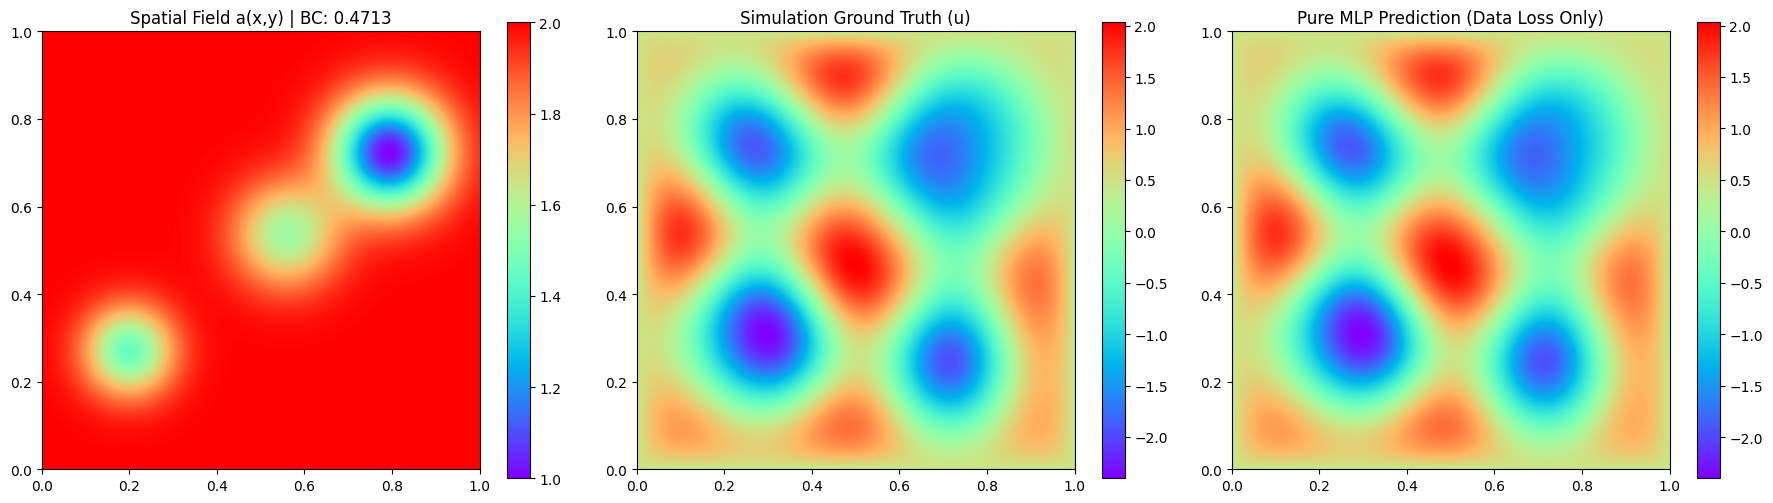

In [9]:
# Predict the full grid directly
u_pred_full = u_pred_vmap(params, x, y)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pure MLP Prediction (Data Loss Only)')

plt.tight_layout()
plt.show()